# Local Outlier Factor - TSI

Notebook independiente para detectar observaciones atípicas con Local Outlier Factor (LOF), seleccionando automáticamente la fuente limpia con mejor cobertura de variables numéricas para evitar distorsiones por nulos o mezclas de calidad desigual. El objetivo es obtener una versión filtrada más interpretable y reutilizable para la siguiente fase del análisis.

In [6]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

In [7]:
feature_candidates = [
    'velocidad',
    'densidad',
    'detenciones',
    'velocity_kmh',
    'density_veh_km',
    'flow_veh_h',
    'wait_time_sec',
    'stops_count',
    'confidence',
    'avg_confidence',
    'speed_congestion',
    'tsi',
    'velocidad_norm',
    'densidad_norm',
    'detenciones_norm',
]

source_candidates = [
    PROJECT_ROOT / 'data' / '02_clean' / 'traffic_enriched.csv',
    PROJECT_ROOT / 'data' / '02_clean' / 'historical_consolidated.csv',
    PROJECT_ROOT / 'data' / '02_clean' / 'traffic_data.csv',
]

candidate_reports = []
candidate_payloads = []

for candidate_path in source_candidates:
    if not candidate_path.exists():
        continue

    candidate_df = pd.read_csv(candidate_path)
    candidate_df.columns = (
        candidate_df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r'[^0-9a-z]+', '_', regex=True)
        .str.replace(r'_+', '_', regex=True)
        .str.strip('_')
    )

    if 'avenida' not in candidate_df.columns and 'road' in candidate_df.columns:
        candidate_df = candidate_df.rename(columns={'road': 'avenida'})

    if 'hora' not in candidate_df.columns and 'hour' in candidate_df.columns:
        candidate_df['hora'] = candidate_df['hour']

    if 'timestamp' in candidate_df.columns:
        candidate_df['timestamp'] = pd.to_datetime(candidate_df['timestamp'], errors='coerce')

    available_features = [column for column in feature_candidates if column in candidate_df.columns]
    if len(available_features) < 3:
        continue

    numeric_frame = candidate_df[available_features].apply(pd.to_numeric, errors='coerce')
    numeric_frame = numeric_frame.loc[:, numeric_frame.nunique(dropna=True) > 1]
    if numeric_frame.shape[1] == 0:
        continue

    min_complete_features = max(3, min(5, numeric_frame.shape[1]))
    usable_mask = numeric_frame.notna().sum(axis=1) >= min_complete_features
    usable_rows = int(usable_mask.sum())
    completeness_ratio = float(numeric_frame.notna().mean().mean())

    candidate_reports.append({
        'source': candidate_path.name,
        'rows': len(candidate_df),
        'features': len(available_features),
        'usable_rows': usable_rows,
        'completeness_ratio': round(completeness_ratio, 4),
        'min_complete_features': min_complete_features,
    })
    candidate_payloads.append({
        'source_path': candidate_path,
        'dataframe': candidate_df,
        'analysis_frame': numeric_frame,
        'available_features': available_features,
        'min_complete_features': min_complete_features,
        'usable_rows': usable_rows,
        'completeness_ratio': completeness_ratio,
        'rows': len(candidate_df),
    })

if not candidate_payloads:
    raise FileNotFoundError('No se encontró un dataset limpio utilizable en data/02_clean')

diagnostics_df = pd.DataFrame(candidate_reports).sort_values(
    by=['completeness_ratio', 'usable_rows', 'rows'],
    ascending=[False, False, False],
).reset_index(drop=True)

best_payload = max(
    candidate_payloads,
    key=lambda item: (item['completeness_ratio'], item['usable_rows'], item['rows']),
)

source_path = best_payload['source_path']
df = best_payload['dataframe'].copy()
analysis_frame = best_payload['analysis_frame'].copy()
available_features = best_payload['available_features']
min_complete_features = best_payload['min_complete_features']

row_mask = analysis_frame.notna().sum(axis=1) >= min_complete_features
df = df.loc[row_mask].copy()
analysis_frame = analysis_frame.loc[row_mask].copy()
analysis_frame = analysis_frame.fillna(analysis_frame.median(numeric_only=True))

scaler = RobustScaler()
X_scaled = scaler.fit_transform(analysis_frame)

n_samples = X_scaled.shape[0]
n_neighbors = min(20, max(5, n_samples - 1))
contamination = 0.08 if n_samples >= 80 else 0.1

lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
lof_labels = lof.fit_predict(X_scaled)
lof_scores = -lof.negative_outlier_factor_

result_df = df.copy()
result_df['lof_label'] = lof_labels
result_df['lof_score'] = lof_scores
result_df['lof_is_anomaly'] = result_df['lof_label'] == -1

anomaly_count = int(result_df['lof_is_anomaly'].sum())
retained_count = int((~result_df['lof_is_anomaly']).sum())
retained_pct = retained_count / len(result_df) * 100
anomaly_pct = anomaly_count / len(result_df) * 100
score_quantiles = pd.Series(lof_scores).quantile([0.0, 0.5, 0.9, 0.95, 0.99, 1.0])

print('Diagnóstico de fuentes candidatas:')
print(diagnostics_df.to_string(index=False))
print()
print(f'Fuente seleccionada: {source_path.name}')
print(f'Registros usados para LOF: {len(result_df):,}')
print(f'Variables utilizadas: {", ".join(available_features)}')
print(f'Umbral mínimo de variables completas por fila: {min_complete_features}')
print()
print(f'Total de registros modelados: {len(result_df):,}')
print(f'Registros retenidos: {retained_count:,} ({retained_pct:.2f}%)')
print(f'Anomalías detectadas: {anomaly_count:,} ({anomaly_pct:.2f}%)')
print()
print('Quantiles de score LOF:')
print(score_quantiles.to_string())
print()
print('Top 10 observaciones más atípicas:')
columns_to_show = ['lof_score', 'lof_label'] + [column for column in ['avenida', 'timestamp'] if column in result_df.columns]
print(result_df.nlargest(10, 'lof_score')[columns_to_show].to_string(index=False))

Diagnóstico de fuentes candidatas:
                     source  rows  features  usable_rows  completeness_ratio  min_complete_features
       traffic_enriched.csv   288         8          288              1.0000                      5
           traffic_data.csv    18         6            0              1.0000                      3
historical_consolidated.csv  5706        10         5040              0.5666                      5

Fuente seleccionada: traffic_enriched.csv
Registros usados para LOF: 288
Variables utilizadas: velocidad, densidad, detenciones, speed_congestion, tsi, velocidad_norm, densidad_norm, detenciones_norm
Umbral mínimo de variables completas por fila: 5

Total de registros modelados: 288
Registros retenidos: 265 (92.01%)
Anomalías detectadas: 23 (7.99%)

Quantiles de score LOF:
0.00    0.947103
0.50    1.020031
0.90    1.195521
0.95    1.293683
0.99    1.616682
1.00    1.980710

Top 10 observaciones más atípicas:
 lof_score  lof_label      avenida           times

In [3]:
feature_candidates = [
    'velocidad',
    'densidad',
    'detenciones',
    'velocity_kmh',
    'density_veh_km',
    'flow_veh_h',
    'wait_time_sec',
    'stops_count',
    'confidence',
    'avg_confidence',
    'speed_congestion',
    'tsi',
    'velocidad_norm',
    'densidad_norm',
    'detenciones_norm',
]

available_features = [column for column in feature_candidates if column in df.columns]
if len(available_features) < 2:
    raise ValueError('No hay suficientes variables numéricas para aplicar LOF')

analysis_frame = df[available_features].apply(pd.to_numeric, errors='coerce')
analysis_frame = analysis_frame.loc[:, analysis_frame.nunique(dropna=True) > 1]
analysis_frame = analysis_frame.fillna(analysis_frame.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(analysis_frame)

n_samples = X_scaled.shape[0]
n_neighbors = min(20, max(2, n_samples - 1))
contamination = 0.08 if n_samples >= 80 else 0.1

lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
lof_labels = lof.fit_predict(X_scaled)
lof_scores = -lof.negative_outlier_factor_

result_df = df.copy()
result_df['lof_label'] = lof_labels
result_df['lof_score'] = lof_scores
result_df['lof_is_anomaly'] = result_df['lof_label'] == -1

anomaly_count = int(result_df['lof_is_anomaly'].sum())
retained_count = int((~result_df['lof_is_anomaly']).sum())
retained_pct = retained_count / len(result_df) * 100
anomaly_pct = anomaly_count / len(result_df) * 100

print('Variables utilizadas para LOF:')
print(', '.join(available_features))
print()
print(f'Total de registros: {len(result_df):,}')
print(f'Registros retenidos: {retained_count:,} ({retained_pct:.2f}%)')
print(f'Anomalías detectadas: {anomaly_count:,} ({anomaly_pct:.2f}%)')
print()
print('Top 10 observaciones más atípicas:')
print(result_df.nlargest(10, 'lof_score')[['lof_score', 'lof_label'] + [column for column in ['avenida', 'timestamp'] if column in result_df.columns]].to_string(index=False))

Variables utilizadas para LOF:
velocidad, densidad, detenciones, velocity_kmh, density_veh_km, flow_veh_h, wait_time_sec, stops_count, confidence, avg_confidence

Total de registros: 5,706
Registros retenidos: 5,249 (91.99%)
Anomalías detectadas: 457 (8.01%)

Top 10 observaciones más atípicas:
 lof_score  lof_label      avenida timestamp
158.890329         -1 Lopez Mateos       NaT
158.890329         -1 Lopez Mateos       NaT
158.890329         -1 Lopez Mateos       NaT
158.890329         -1 Lopez Mateos       NaT
158.890329         -1 Lopez Mateos       NaT
158.890329         -1 Lopez Mateos       NaT
158.890329         -1 Lopez Mateos       NaT
158.890329         -1 Lopez Mateos       NaT
158.890329         -1 Lopez Mateos       NaT
158.890329         -1 Lopez Mateos       NaT


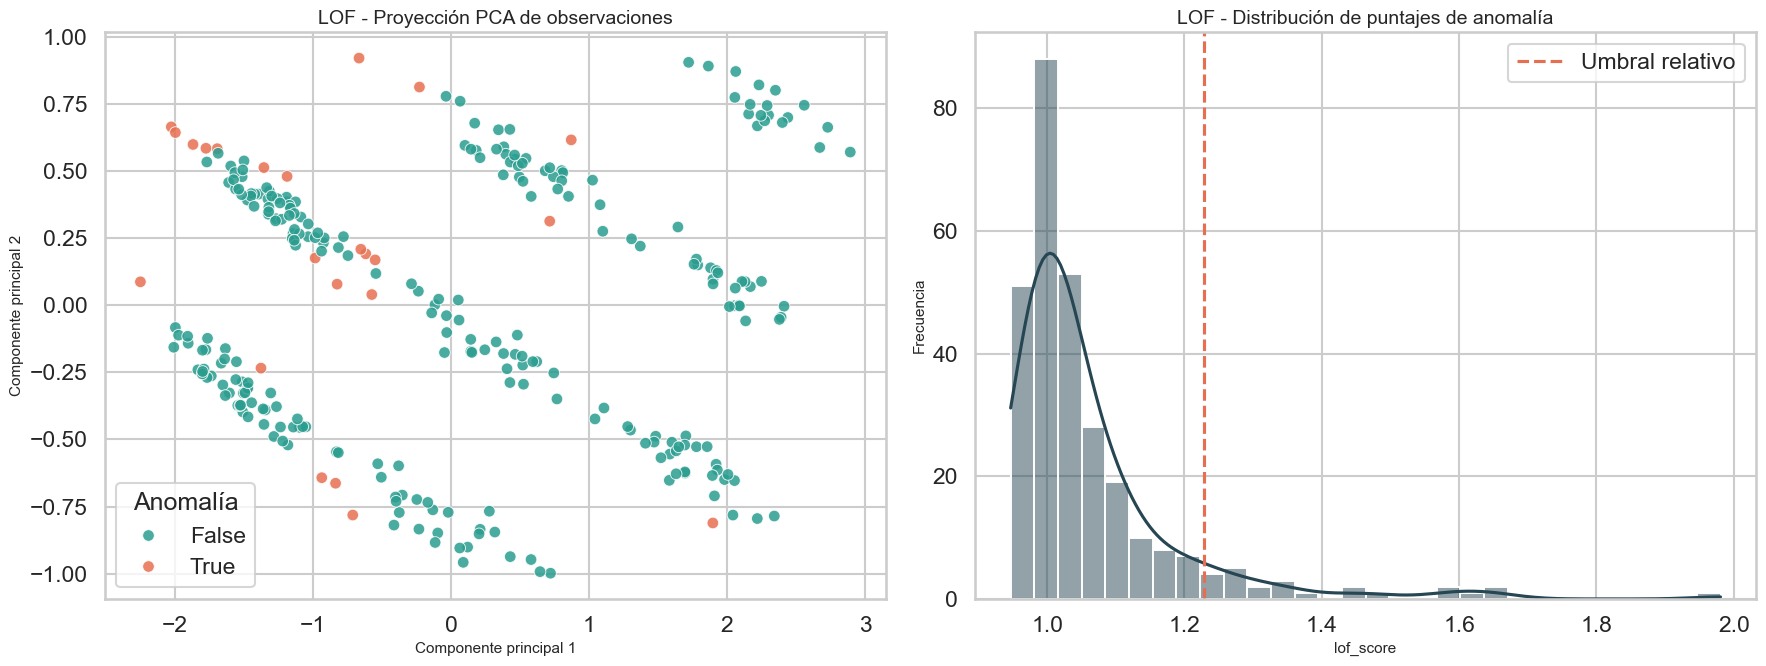

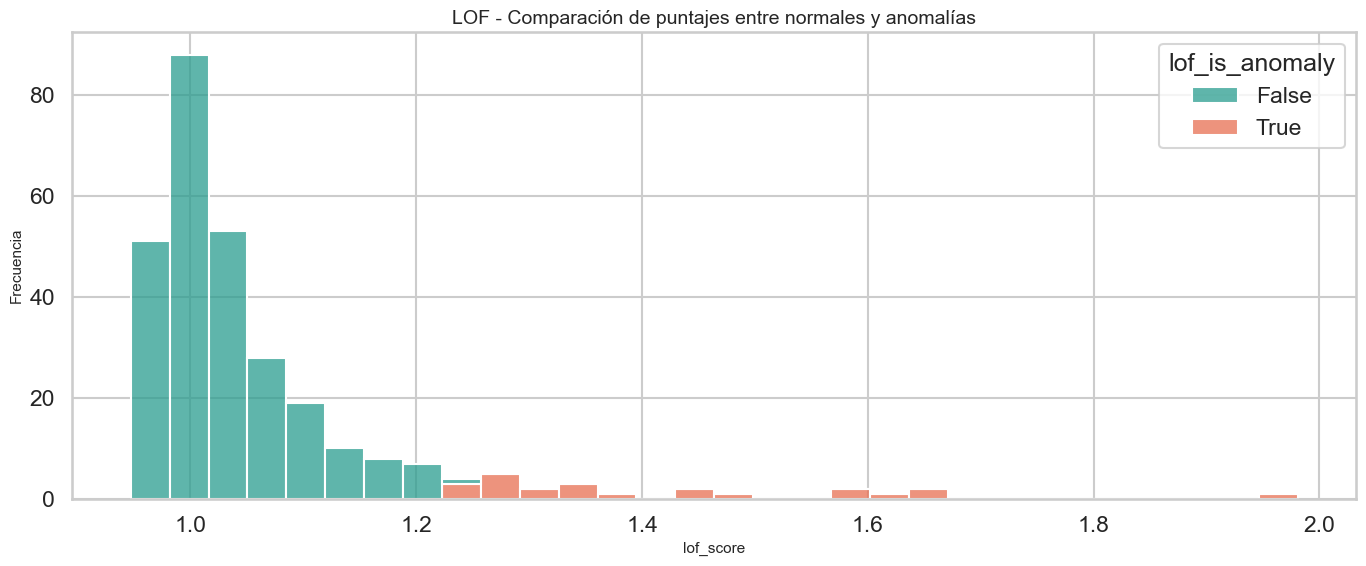

Archivo limpio guardado en: c:\Users\REYES\OneDrive\Desktop\TSI\data\02_clean\filtered_local_outlier_factor.csv
Anomalías guardadas en: c:\Users\REYES\OneDrive\Desktop\TSI\data\03_algorithm_output\local_outlier_factor_anomalies.csv
Resumen guardado en: c:\Users\REYES\OneDrive\Desktop\TSI\data\03_algorithm_output\local_outlier_factor_summary.csv
Gráfico PCA guardado en: c:\Users\REYES\OneDrive\Desktop\TSI\data\03_algorithm_output\local_outlier_factor_pca.png
Gráfico de puntajes guardado en: c:\Users\REYES\OneDrive\Desktop\TSI\data\03_algorithm_output\local_outlier_factor_scores.png


In [8]:
filtered_df = result_df.loc[~result_df['lof_is_anomaly']].copy()
anomalies_df = result_df.loc[result_df['lof_is_anomaly']].copy()

clean_output_path = PROJECT_ROOT / 'data' / '02_clean' / 'filtered_local_outlier_factor.csv'
algorithm_output_dir = PROJECT_ROOT / 'data' / '03_algorithm_output'
algorithm_output_dir.mkdir(parents=True, exist_ok=True)

anomalies_output_path = algorithm_output_dir / 'local_outlier_factor_anomalies.csv'
summary_output_path = algorithm_output_dir / 'local_outlier_factor_summary.csv'
plot_output_path = algorithm_output_dir / 'local_outlier_factor_pca.png'
score_plot_path = algorithm_output_dir / 'local_outlier_factor_scores.png'

filtered_df.to_csv(clean_output_path, index=False)
anomalies_df.to_csv(anomalies_output_path, index=False)

summary_df = pd.DataFrame([
    {'metric': 'total_registros', 'value': len(result_df)},
    {'metric': 'registros_retenidos', 'value': len(filtered_df)},
    {'metric': 'anomalias_detectadas', 'value': len(anomalies_df)},
    {'metric': 'porcentaje_retenido', 'value': round(len(filtered_df) / len(result_df) * 100, 2)},
    {'metric': 'porcentaje_anomalia', 'value': round(len(anomalies_df) / len(result_df) * 100, 2)},
    {'metric': 'variables_usadas', 'value': ', '.join(available_features)},
    {'metric': 'n_neighbors', 'value': n_neighbors},
    {'metric': 'contamination', 'value': contamination},
])
summary_df.to_csv(summary_output_path, index=False)

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)
plot_df = pd.DataFrame({
    'pca_1': components[:, 0],
    'pca_2': components[:, 1],
    'lof_is_anomaly': result_df['lof_is_anomaly'].values,
})
if 'avenida' in result_df.columns:
    plot_df['avenida'] = result_df['avenida'].astype(str).values

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    data=plot_df,
    x='pca_1',
    y='pca_2',
    hue='lof_is_anomaly',
    palette={False: '#2a9d8f', True: '#e76f51'},
    s=70,
    alpha=0.85,
    ax=axes[0],
)
axes[0].set_title('LOF - Proyección PCA de observaciones')
axes[0].set_xlabel('Componente principal 1')
axes[0].set_ylabel('Componente principal 2')
axes[0].legend(title='Anomalía', loc='best')

sns.histplot(result_df['lof_score'], bins=30, kde=True, color='#264653', ax=axes[1])
axes[1].axvline(result_df.loc[result_df['lof_is_anomaly'], 'lof_score'].min(), color='#e76f51', linestyle='--', label='Umbral relativo')
axes[1].set_title('LOF - Distribución de puntajes de anomalía')
axes[1].set_xlabel('lof_score')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.savefig(plot_output_path, dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
sns.histplot(data=result_df, x='lof_score', hue='lof_is_anomaly', bins=30, multiple='stack', palette={False: '#2a9d8f', True: '#e76f51'}, ax=ax)
ax.set_title('LOF - Comparación de puntajes entre normales y anomalías')
ax.set_xlabel('lof_score')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig(score_plot_path, dpi=160, bbox_inches='tight')
plt.show()

print(f'Archivo limpio guardado en: {clean_output_path}')
print(f'Anomalías guardadas en: {anomalies_output_path}')
print(f'Resumen guardado en: {summary_output_path}')
print(f'Gráfico PCA guardado en: {plot_output_path}')
print(f'Gráfico de puntajes guardado en: {score_plot_path}')

## Cierre

Este notebook deja una implementación independiente de LOF conectada a los CSV limpios del proyecto TSI. El siguiente paso natural es replicar la misma lógica para DBSCAN y luego comparar los tres enfoques con métricas homogéneas antes de consolidar la métrica final TSI.